In [2]:
import sys
import os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from hyperQUAD.quad_control import HyperQuadControl
import numpy as np
from joblib import Parallel, delayed
import time 

import matplotlib.pyplot as plt

In [3]:
# ham_args = (100, 10, 15, 1, .1) #U, tc, Ez, dEz, dEx
ham_args = (10, 1, .9, 0.1, 0.01) #U, tc, Ez, dEz, dEx

def DQD_5(e, *ham_args):
    
    U = ham_args[0]
    tc = ham_args[1]
    Ez = ham_args[2]
    dEz = ham_args[3]
    dEx = ham_args[4]
    
    ham = np.array([
        [U-e, 0, -tc, tc, 0],
        [0, Ez, dEx, -dEx, 0],
        [-tc, dEx, dEz, 0, dEx],
        [tc, -dEx, 0, -dEz, -dEx],
        [0, 0, dEx, -dEx, -Ez]
    ])
    return ham

def partial_ham(*ham_args):
    partial_ham = np.array([[-1, 0, 0, 0, 0],
                            [0, 0, 0, 0, 0],
                            [0, 0, 0, 0, 0],
                            [0, 0, 0, 0, 0],
                            [0, 0, 0, 0, 0]])
    return partial_ham


dqd = HyperQuadControl(
    
                hamiltonian=DQD_5, 
                partial_hamiltonian=partial_ham, 
                control_init=15, 
                control_final=0, 
                ham_args=ham_args,
                initial_state=0,
                final_state=1,
                control_method='diad',
                alpha=2,
                beta=2,
                               )


dqd_ad = HyperQuadControl(
    
                hamiltonian=DQD_5, 
                partial_hamiltonian=partial_ham, 
                control_init=15, 
                control_final=0, 
                ham_args=ham_args,
                initial_state=0,
                final_state=0,
                control_method='hyperQUAD'
                               )



In [4]:
#Diabatic fidelity map
def compute_max_fidelities(model, sweep, dia_alpha, dia_beta):

    model.update_params(dia_alpha=dia_alpha, dia_beta=dia_beta)   
    fidelities = model.fidelity_sweep(sweep, infidelity=False)
    
    return fidelities


def fidelity_map_parallel(model, steps, sweep, times, alpha_beta_list, n_jobs):
    def compute_fidelity(i, j):
        (dia_alpha, dia_beta) = alpha_beta_list[i, j]
        return compute_max_fidelities(model, sweep, dia_alpha, dia_beta)

    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_fidelity)(i, j) for i in range(steps) for j in range(steps)
    )

    fidelities = np.zeros((steps, steps, len(times)))
    for idx, (i, j) in enumerate([(i, j) for i in range(steps) for j in range(steps)]):
        fidelities[i, j] = results[idx]

    return fidelities



#Adiabatic fidelity map
def compute_max_fidelities_adiabatic(model, sweep, alpha, beta):

    model.update_params(alpha=alpha, beta=beta)   
    fidelities = model.fidelity_sweep(sweep, infidelity=False)
    
    return fidelities


def fidelity_map_parallel_adiabatic(model, steps, sweep, times, alpha_beta_list, n_jobs):
    def compute_fidelity(i, j):
        (alpha, beta) = alpha_beta_list[i, j]
        return compute_max_fidelities_adiabatic(model, sweep, alpha, beta)

    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_fidelity)(i, j) for i in range(steps) for j in range(steps)
    )

    fidelities = np.zeros((steps, steps, len(times)))
    for idx, (i, j) in enumerate([(i, j) for i in range(steps) for j in range(steps)]):
        fidelities[i, j] = results[idx]

    return fidelities

In [5]:
times = np.linspace(.01, 1000, 20) 
sweep = {'pulse_time': times}

steps = 10
alphas = np.linspace(-5, 5, steps)
betas = alphas
alpha_beta_list = [(alpha, beta) for alpha in alphas for beta in betas]
alpha_beta_list = np.array(alpha_beta_list).reshape(steps, steps, 2)

In [ ]:
overall_start = time.time()

n_jobs = -1
model = dqd 
fidelities = fidelity_map_parallel(model, steps, sweep, times, alpha_beta_list, n_jobs=n_jobs)

overall_end = time.time()
print(f"\nTotal time (paralellized): {overall_end - overall_start:.4f} seconds")

Sweeping pulse_time:  25%|██▌       | 5/20 [00:18<00:55,  3.72s/it]

In [ ]:
print(np.max(fidelities, axis=2).max())

In [ ]:
overall_start = time.time()

n_jobs = -1
model = dqd_ad
fidelities_ad = fidelity_map_parallel_adiabatic(model, steps, sweep, times, alpha_beta_list, n_jobs=n_jobs)

overall_end = time.time()
print(f"\nTotal time (paralellized): {overall_end - overall_start:.4f} seconds")

In [9]:
print(np.max(fidelities_ad, axis=2).max())

0.9999868037985804


Plotting (adiabatic, diabatic) fidelity maps

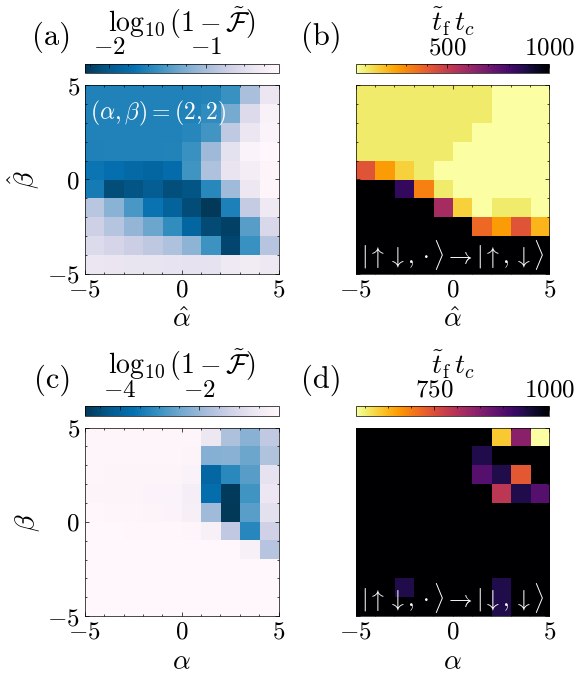

In [10]:
max_fidelity = np.max(fidelities, axis=2)
best_times = times[np.argmax(fidelities, axis=2)]

max_fidelity_ad = np.max(fidelities_ad, axis=2)
best_times_ad = times[np.argmax(fidelities_ad, axis=2)]



import scienceplots
plt.style.use(['science', 'no-latex'])

fig, axs = plt.subplots(2, 2, figsize=(6, 7), sharey=True)

fontsizes = 18
fontsize_label = 20
colorbar_loc = 'top'
cmap_coloring_fid = 'PuBu_r'

# Diabatic set
im0 = axs[0, 0].imshow(np.log10(1 - max_fidelity.T), origin='lower', aspect='auto', interpolation='none',
                       extent=[min(alphas), max(alphas), min(betas), max(betas)], cmap=cmap_coloring_fid)
axs[0, 0].text(0.38, 0.85, r'$(\alpha,\beta)=(2,2)$', fontsize=17, color='white',
               ha='center', va='center', transform=axs[0, 0].transAxes)

cbar0 = plt.colorbar(im0, ax=axs[0, 0], label=r'$\log_{10}(1 - \tilde{\mathcal{F}})$', location=colorbar_loc)
cbar0.ax.tick_params(labelsize=fontsizes)
cbar0.ax.xaxis.label.set_size(fontsize_label)

im1 = axs[0, 1].imshow(best_times.T, origin='lower', aspect='auto', interpolation='none',
                       extent=[min(alphas), max(alphas), min(betas), max(betas)], cmap='inferno_r')
axs[0, 1].text(0.5, 0.1, r'$|\uparrow\downarrow, \cdot\rangle \to |\uparrow, \downarrow\rangle$', fontsize=17, color='white',
               ha='center', va='center', transform=axs[0, 1].transAxes)

cbar1 = plt.colorbar(im1, ax=axs[0, 1], label=r'$\tilde{t}_\text{f}\,t_c$', location=colorbar_loc)
cbar1.ax.tick_params(labelsize=fontsizes)
cbar1.ax.xaxis.label.set_size(fontsize_label)


# Adiabatic set
im2 = axs[1, 0].imshow(np.log10(1 - max_fidelity_ad.T), origin='lower', aspect='auto', interpolation='none',
                       extent=[min(alphas), max(alphas), min(betas), max(betas)], cmap=cmap_coloring_fid)

                    
cbar2 = plt.colorbar(im2, ax=axs[1, 0], label=r'$\log_{10}(1 - \tilde{\mathcal{F}})$', location=colorbar_loc)
cbar2.ax.tick_params(labelsize=fontsizes)
cbar2.ax.xaxis.label.set_size(fontsize_label)
# cbar2.set_ticks([-1, -3, -5])

im3 = axs[1, 1].imshow(best_times_ad.T, origin='lower', aspect='auto', interpolation='none',
                       extent=[min(alphas), max(alphas), min(betas), max(betas)], cmap='inferno_r')
axs[1, 1].text(.5, 0.1,  r'$|\uparrow\downarrow, \cdot\rangle \to |\downarrow, \downarrow\rangle$', fontsize=17, color='white',
               ha='center', va='center', transform=axs[1, 1].transAxes)

cbar3 = plt.colorbar(im3, ax=axs[1, 1], label=r'$\tilde{t}_\text{f}\,t_c$', location=colorbar_loc)
cbar3.ax.tick_params(labelsize=fontsizes)
cbar3.ax.xaxis.label.set_size(fontsize_label)


# Label axes
fontsize_label = 20

axs[0,0].set_ylabel(r'$\hat{\beta}$', fontsize=fontsize_label)
axs[0,0].set_xlabel(r'$\hat{\alpha}$', fontsize=fontsize_label)

axs[0,1].set_xlabel(r'$\hat{\alpha}$', fontsize=fontsize_label)
# axs[0,1].set_ylabel(r'$\hat{\beta}$', fontsize=fontsize_label)

axs[1,0].set_ylabel(r'$\beta$', fontsize=fontsize_label)
axs[1,0].set_xlabel(r'$\alpha$', fontsize=fontsize_label)

axs[1,1].set_xlabel(r'$\alpha$', fontsize=fontsize_label)
# axs[1,1].set_ylabel(r'$\beta$', fontsize=fontsize_label)

for i,j in [(0, 0), (0, 1), (1, 0), (1, 1)]:
    axs[i,j].tick_params(labelsize=18)

for i, ax in enumerate(axs.flat):
    idx_list_flat = [0,1,2,3] 
    offset_y = 0.26 if i in idx_list_flat else 0.0  
    ax.text(-0.07, 1.08 + offset_y, f'({chr(97 + i)})',
            transform=ax.transAxes,
            fontsize=22, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.show()


/tmp/ipykernel_2823133/3579976111.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


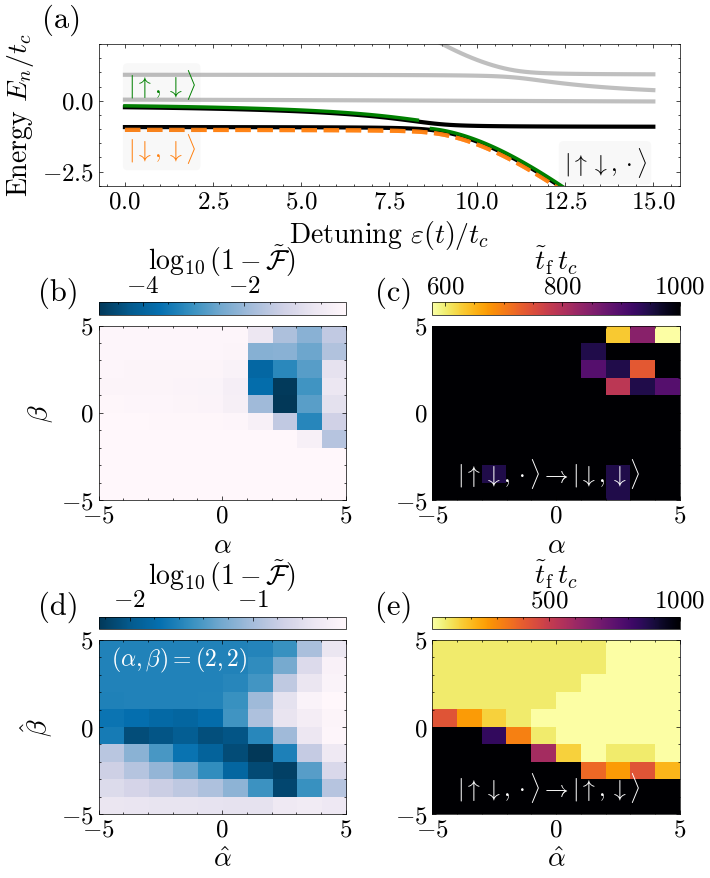

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'no-latex'])

# ======================
# Data processing
# ======================
max_fidelity = np.max(fidelities, axis=2)
best_times = times[np.argmax(fidelities, axis=2)]

max_fidelity_ad = np.max(fidelities_ad, axis=2)
best_times_ad = times[np.argmax(fidelities_ad, axis=2)]

# ======================
# Figure + GridSpec
# ======================
fig = plt.figure(figsize=(7.5, 10))
gs = fig.add_gridspec(3, 2, height_ratios=[1.3, 2, 2], hspace=0.5, wspace=0.35)

ax_top = fig.add_subplot(gs[0, :])
axs = np.array([
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
    [fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1])]
])

fontsizes = 18
fontsize_label = 20
colorbar_loc = 'top'
cmap_coloring_fid = 'PuBu_r'
xmin, xmax = min(alphas), max(alphas)

# ======================
# TOP PANEL: linear function
# ======================
ham_args = (10, 1, .9, 0.1, 0.1) #U, tc, Ez, dEz, dEx

e_vals = np.linspace(0, 15, 100)
hams = np.array([DQD_5(e, *ham_args) for e in e_vals])

energies, _ = np.linalg.eigh(hams)
for n in range(5):
    if n in [0,1]:
        ax_top.plot(e_vals, energies[:, n], linewidth=3, color='black', linestyle='-', alpha=1)
        ax_top.plot(e_vals, energies[:, 0]-0.1, linewidth=3, color='tab:orange', linestyle='--', alpha=0.8)
        
    else:
        ax_top.plot(e_vals, energies[:, n], linewidth=3, color='gray', linestyle='-', alpha=0.5)


e_vals1 = np.linspace(0, 8.3, 100)
e_vals2 = np.linspace(8.7, 15, 100)
hams1 = np.array([DQD_5(e, *ham_args) for e in e_vals1])
hams2 = np.array([DQD_5(e, *ham_args) for e in e_vals2])
energies1, _ = np.linalg.eigh(hams1)
energies2, _ = np.linalg.eigh(hams2)
ax_top.plot(e_vals1, energies1[:, 1]+0.05, linewidth=2.5, color='green', linestyle='-', alpha=1)
ax_top.plot(e_vals2, energies2[:, 0]+0.05, linewidth=2.5, color='green', linestyle='-', alpha=1)


ax_top.set_ylabel(r"Energy $E_n/t_c$", fontsize=fontsize_label)
ax_top.set_xlabel(r"Detuning $\varepsilon(t)/t_c$", fontsize=fontsize_label)
ax_top.tick_params(labelsize=fontsizes)
ax_top.text(-0.03, 1.28, "(a)", transform=ax_top.transAxes,
            fontsize=22, fontweight="bold", va="top", ha="right")
ax_top.set_ylim(-3, 2)


ax_top.text(0.8, 0.1, r'$|\uparrow\downarrow, \cdot\rangle$', fontsize=17, color='black', transform=ax_top.transAxes, bbox=dict(facecolor='gray', alpha=0.05, edgecolor='none', boxstyle='round,pad=0.2'))
ax_top.text(0.05, 0.2, r'$|\downarrow,\downarrow\rangle$', fontsize=17, color='tab:orange', transform=ax_top.transAxes, bbox=dict(facecolor='gray', alpha=0.05, edgecolor='none', boxstyle='round,pad=0.2'))
ax_top.text(0.05, 0.65, r'$|\uparrow, \downarrow\rangle$', fontsize=17, color='green', transform=ax_top.transAxes, bbox=dict(facecolor='gray', alpha=0.05, edgecolor='none', boxstyle='round,pad=0.2'))



# ======================
# Diabatic set
# ======================
im0 = axs[1, 0].imshow(
    np.log10(1 - max_fidelity.T),
    origin='lower', aspect='auto', interpolation='none',
    extent=[xmin, xmax, min(betas), max(betas)],
    cmap=cmap_coloring_fid
)

axs[1, 0].text(0.05, 0.85, r'$(\alpha,\beta)=(2,2)$',
               fontsize=17, color='white',
               transform=axs[1, 0].transAxes)

cbar0 = plt.colorbar(im0, ax=axs[1, 0],
                     label=r'$\log_{10}(1 - \tilde{\mathcal{F}})$',
                     location=colorbar_loc)
cbar0.ax.tick_params(labelsize=fontsizes)
cbar0.ax.xaxis.label.set_size(fontsize_label)

im1 = axs[1, 1].imshow(
    best_times.T,
    origin='lower', aspect='auto', interpolation='none',
    extent=[xmin, xmax, min(betas), max(betas)],
    cmap='inferno_r'
)

axs[1, 1].text(0.1, 0.1,
               r'$|\uparrow\downarrow, \cdot\rangle \to |\uparrow, \downarrow\rangle$',
               fontsize=17, color='white',
               transform=axs[1, 1].transAxes)

cbar1 = plt.colorbar(im1, ax=axs[1, 1],
                     label=r'$\tilde{t}_\text{f}\,t_c$',
                     location=colorbar_loc)
cbar1.ax.tick_params(labelsize=fontsizes)
cbar1.ax.xaxis.label.set_size(fontsize_label)

# ======================
# Adiabatic set
# ======================
im2 = axs[0, 0].imshow(
    np.log10(1 - max_fidelity_ad.T),
    origin='lower', aspect='auto', interpolation='none',
    extent=[xmin, xmax, min(betas), max(betas)],
    cmap=cmap_coloring_fid
)

cbar2 = plt.colorbar(im2, ax=axs[0, 0],
                     label=r'$\log_{10}(1 - \tilde{\mathcal{F}})$',
                     location=colorbar_loc)
cbar2.ax.tick_params(labelsize=fontsizes)
cbar2.ax.xaxis.label.set_size(fontsize_label)

im3 = axs[0, 1].imshow(
    best_times_ad.T,
    origin='lower', aspect='auto', interpolation='none',
    extent=[xmin, xmax, min(betas), max(betas)],
    cmap='inferno_r'
)

axs[0, 1].text(0.1, 0.1,
               r'$|\uparrow\downarrow, \cdot\rangle \to |\downarrow, \downarrow\rangle$',
               fontsize=17, color='white',
               transform=axs[0, 1].transAxes)

cbar3 = plt.colorbar(im3, ax=axs[0, 1],
                     label=r'$\tilde{t}_\text{f}\,t_c$',
                     location=colorbar_loc)
cbar3.ax.tick_params(labelsize=fontsizes)
cbar3.ax.xaxis.label.set_size(fontsize_label)

# ======================
# Axis labels
# ======================
axs[1, 0].set_ylabel(r'$\hat{\beta}$', fontsize=fontsize_label)
axs[1, 0].set_xlabel(r'$\hat{\alpha}$', fontsize=fontsize_label)

axs[1, 1].set_xlabel(r'$\hat{\alpha}$', fontsize=fontsize_label)

axs[0, 0].set_ylabel(r'$\beta$', fontsize=fontsize_label)
axs[0, 0].set_xlabel(r'$\alpha$', fontsize=fontsize_label)

axs[0, 1].set_xlabel(r'$\alpha$', fontsize=fontsize_label)

# ======================
# Styling + panel labels
# ======================
for ax in axs.flat:
    ax.tick_params(labelsize=18)

panel_labels = ['(b)', '(c)', '(d)', '(e)']
for ax, lab in zip(axs.flat, panel_labels):
    ax.text(-0.08, 1.28, lab,
            transform=ax.transAxes,
            fontsize=22, fontweight='bold',
            va='top', ha='right')
    
plt.tight_layout()
plt.show()

# Runtime analysis

In [38]:
def cpu_runtime(model, alpha, beta, num_cpu_runs, adia: bool = False):
    runtimes = []
    for _ in range(num_cpu_runs):
        start_time = time.time()
        
        if adia:
            model.update_params(alpha=alpha, beta=beta)
            _, _ = model.compute_optimal_pulse()
        else:
            model.update_params(alpha=2, beta=2, dia_alpha=alpha, dia_beta=beta)
            _, _ = model.compute_optimal_pulse()
            
        end_time = time.time()
        runtimes.append(end_time - start_time) 
    return np.median(runtimes), np.std(runtimes)

def run_grid_parallel(model, alphas, betas, num_cpu_runs=3, adia=False, n_jobs=-1):
    pairs = [(a, b) for a in alphas for b in betas]
    results = Parallel(n_jobs=n_jobs)(
        delayed(cpu_runtime)(model, a, b, num_cpu_runs, adia) for a, b in pairs
    )
    means = np.zeros((len(alphas), len(betas)))
    stds  = np.zeros((len(alphas), len(betas)))
    for idx,(mean,std) in enumerate(results):
        i, j = divmod(idx, len(betas))
        means[i,j], stds[i,j] = mean, std
    return means, stds


steps = 10
alphas = np.linspace(-4, 4, steps)
betas = alphas
alpha_beta_list = [(alpha, beta) for alpha in alphas for beta in betas]
alpha_beta_list = np.array(alpha_beta_list).reshape(steps, steps, 2)

In [39]:
model = dqd
start_time = time.time()
means, stds = run_grid_parallel(model, alphas, betas, num_cpu_runs=100, adia=False, n_jobs=50)

print("Total time: ", time.time()-start_time)

Total time:  444.84117817878723


In [40]:
model = dqd_ad
start_time = time.time()
means_ad, stds_ad = run_grid_parallel(model, alphas, betas, num_cpu_runs=100, adia=True, n_jobs=50)

print("Total time: ", time.time()-start_time)

Total time:  370.6224765777588


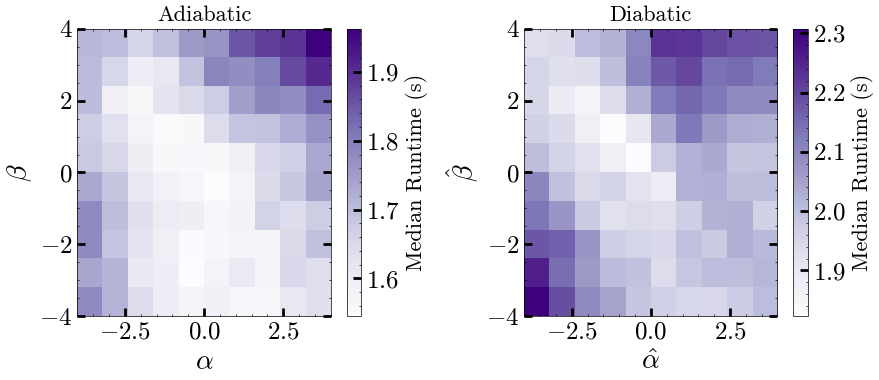

In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(9, 4))


import scienceplots
plt.style.use(['science', 'no-latex'])

# Plot first heatmap
im1 = axes[0].imshow(means_ad, extent=[betas[0], betas[-1], alphas[0], alphas[-1]],
                     origin='lower', aspect='auto', cmap='Purples')
axes[0].set_title("Adiabatic", fontsize=16)
cbar1 = fig.colorbar(im1, ax=axes[0])
cbar1.set_label("Median Runtime (s)", fontsize=16)  # label font size
cbar1.ax.tick_params(labelsize=18, width=2, length=6)  # tick size + line width

# Plot second heatmap
im2 = axes[1].imshow(means, extent=[betas[0], betas[-1], alphas[0], alphas[-1]],
                     origin='lower', aspect='auto', cmap='Purples')
axes[1].set_title("Diabatic", fontsize=16)
cbar2 = fig.colorbar(im2, ax=axes[1])
cbar2.set_label("Median Runtime (s)", fontsize=16)  # label font size
cbar2.ax.tick_params(labelsize=18, width=2, length=6)

# Axis labels
fontsize_label = 20
axes[1].set_ylabel(r'$\hat{\beta}$', fontsize=fontsize_label)
axes[1].set_xlabel(r'$\hat{\alpha}$', fontsize=fontsize_label)

axes[0].set_xlabel(r'$\alpha$', fontsize=fontsize_label)
axes[0].set_ylabel(r'$\beta$', fontsize=fontsize_label)

# Bigger tick labels for both main plots
for ax in axes:
    ax.tick_params(labelsize=18, width=2, length=6)

plt.tight_layout()
plt.show()


# Pulses plot


In [46]:
def pulses_list(alpha, beta, adia: bool = False):
    dqd.update_params(alpha=2, beta=2, dia_alpha=alpha, dia_beta=beta)
    times_dia, pulses_dia = dqd.compute_optimal_pulse()
    
    dqd_ad.update_params(alpha=alpha, beta=beta)
    times_ad, pulses_ad = dqd_ad.compute_optimal_pulse()
    
    if adia:
        return (times_ad, pulses_ad)
    else:
        return (times_dia, pulses_dia)


In [47]:
s, sol = pulses_list(3, -3, adia=False)
s_ad, sol_ad = pulses_list(2, 2, adia=True)

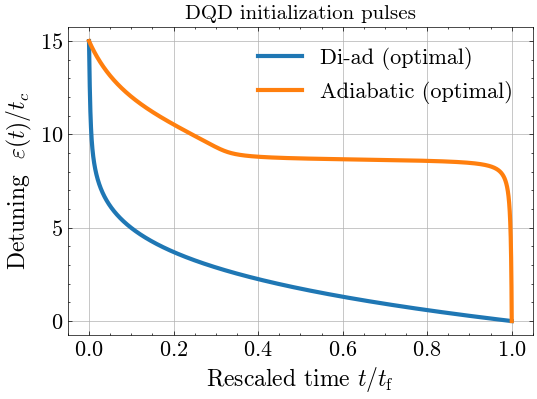

In [49]:
plt.figure(figsize=(6,4))
plt.plot(s, sol, label='Di-ad (optimal)', color='tab:blue', lw=3)
plt.plot(s_ad, sol_ad, label='Adiabatic (optimal)', color='tab:orange', lw=3)
plt.xlabel(r'Rescaled time $t/t_\text{f}$', fontsize=17)
plt.ylabel(r'Detuning  $\varepsilon(t)/t_c$', fontsize=17)
plt.title('DQD initialization pulses', fontsize=15)
plt.tick_params(labelsize=16)
plt.grid(True)
plt.legend(fontsize=16)